# **Few-shot protein-family generation with ProtGPT3-MSA**

**Notebook developed by Noelia Ferruz.**

In this practical we will use **seven confirmed defluorinase sequences** (the only ones for which there is experimental confirmation they defluorinate, yet not dechlorinate) to prompt ProtGPT3-MSA. We will:

1. inspect the seven sequences we have
2. explain what happens when we fine-tune with those seven instead
3. generate additional family-conditioned sequences without updating the model
4. predict and display structurs
5. test copying and mutation recovery with 15 variants from the MegaScale stability dataset (which contains only single mutants).

> Select **Runtime → Change runtime type → T4 GPU** before starting.


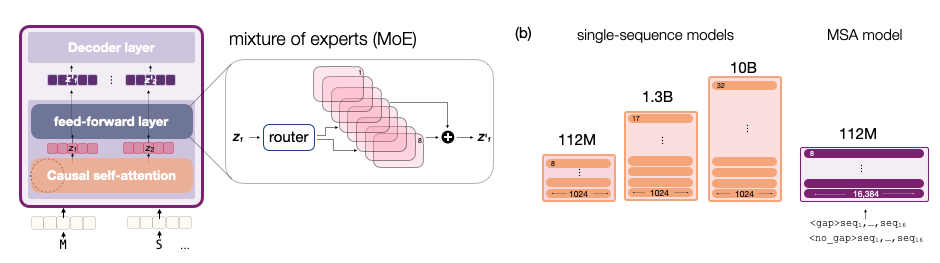

## **1. Setup**

In [1]:
%pip install -q "transformers==4.53.3" accelerate biopython py3Dmol requests

In [2]:
%pip install py3Dmol

In [3]:
import requests
import torch
import py3Dmol
from Bio import Align
from transformers import AutoModelForCausalLM, AutoTokenizer

assert torch.cuda.is_available(), "Please select a GPU runtime and run again."
torch.manual_seed(7)
print(torch.cuda.get_device_name(0))


Tesla T4


## **2. Start with the data we really have**

These are the seven defluorinases, coming from different species. Because they are few, we can directly put them into our notebook.


In [4]:
defluorinases = [
    "MHAIKAVVFDLYGTLYDVYSVRTSCERIFPGQGEMVSKMWRQKQLEYTWMRTLMGQYQDFESATLDALRYTCGSLGLALDADGEAHLCSEYLSLTPFADVPQALQQLRAAGLKTAILSNGSRHSIRQVVGNSGLTNSFDHLISVDEVRLFKPHQKVYELAMDTLHLGESEILFVSCNSWDATGAKYFGYPVCWINRSNGVFDQLGVVPDIVVSDVGVLASRFSPVDEAA",
    "MEKPRALAPVPIRGVLFDAYGTLFDVYSVGLLAEQLFPGQGQTLGLLWRDKQIEYTRLVTTCNDGAHYQPFWDLTRSSLRYVCKRLALDLTPEREQRLMNQYRHLSAFPENKGVLQALKKRGIVTGILSNGDPSMLDVAVKSGGLEGLLDHVISVDSIRKYKTHPDAYALGPQHTGLDVRQIAFVSCNGWDALAATWYGYQTLWINRYQLPFEELGTAPTYTGSSLRDVLTLPGMNLPGAAA",
    "MAAAAGYSGERETAMIEAIAFDAYGTLYDVYSVERKCEEEYPGSGAAMSRLWRQKQLEYSWLRTLMGRYADFWRVTEDALRYTLAELGLEGDEGKIAAIMATYLELEMYPEVIEAMARFGTRKKAILTNGNLGMIQPLVARSGLGAHLDACLSADEAGLFKVRPEVYQLAVDHLGVARERLLFVSSNGWDVAGAKAFGFTVGWLNRRGLPPEELGVRADYEASNLLELAEMVVSA",
    "MIEAIAFDAYGTLYDVYSVERKCEEEYPGSGAAMSRLWRQKQLEYSWLRTLMGRYADFWRVTEDALRYTLAELGLEGDEGKIAAIMATYLELEMYPEVIEAMARFGTRKKAILTNGNLGMIEPLVARSGLDAHLDACLSADEAGLFKVRPEVYQLAVDHLGVARERLLFVSSNGWDVAGAKAFGFTVGWLNRRGLPPEELGVRADYEASNLLELTEMVVSA",
    "MHHSPKIKVLAFDIFGTVVDWHSSIVQEVKSLALNIDANQFALDWRAGYRPAMDQVLSGQQPWTSIDDIHRLILDELLAKYQISTLTEAQKMDLNFIWHRLNPWPDTVAALNQLKQDYIICTLSNGNIRLLVDLAKYAKLPWDTIFSAENFKAYKLSPKTYLGVSDFLNVAPSQVMMVATHQDDLAAARGCGLRTAYIERPFEYGAAQLKDSSPCIDNNLHATDLLNLVSLLKEKA",
    "MAGVPFRSPSTGRNVRAVLFDTFGTVVDWRTGIATAVADYAARHQLEVDAVAFADRWRARYQPSMDAILSGAREFVTLDILHRENLDFVLRESGIDPTNHDSGELDELARAWHVLTPWPDSVPGLTAIKAEYIIGPLSNGNTSLLLDMAKNAGIPWDVIIGSDINRKYKPDPQAYLRTAQVLGLHPGEVMLAAAHNGDLEAAHATGLATAFILRPVEHGPHQTDDLAPTGSWDISATDITDLAAQLRAGSTGFR",
    "MDVSNVRIVIFDTFGTVVNWHESVVQEGEALGRAKGVSIDWHEFANVWREEGYIKVMYEVAQGLRPWEPVDVLHRRKLDELLDVYGLKLTEEETDHFNRLWHRLLPWPDVQEGLRRLKTKYSIGPFSNGDFRLLLNMAKGSGLPWDFILAGQQFQKFKPDPTIYEDAVELLGGRPEEVLMVAAHPSDLDGAHAIGCPTLYVPRPLEYGAVNNHVEPEAKYDHETVADFRELAARLGV",
]


**Mini-exercise.** The list contains the complete input data. Before running the next cell, compute the sequence length (and optionally their sequence identity)


In [5]:
print(f"We have only {len(defluorinases)} sequences.\n")
for number, sequence in enumerate(defluorinases, 1):
    print(f"Sequence {number} | {len(sequence)} aa\n{sequence}\n")

We have only 7 sequences.

Sequence 1 | 229 aa
MHAIKAVVFDLYGTLYDVYSVRTSCERIFPGQGEMVSKMWRQKQLEYTWMRTLMGQYQDFESATLDALRYTCGSLGLALDADGEAHLCSEYLSLTPFADVPQALQQLRAAGLKTAILSNGSRHSIRQVVGNSGLTNSFDHLISVDEVRLFKPHQKVYELAMDTLHLGESEILFVSCNSWDATGAKYFGYPVCWINRSNGVFDQLGVVPDIVVSDVGVLASRFSPVDEAA

Sequence 2 | 242 aa
MEKPRALAPVPIRGVLFDAYGTLFDVYSVGLLAEQLFPGQGQTLGLLWRDKQIEYTRLVTTCNDGAHYQPFWDLTRSSLRYVCKRLALDLTPEREQRLMNQYRHLSAFPENKGVLQALKKRGIVTGILSNGDPSMLDVAVKSGGLEGLLDHVISVDSIRKYKTHPDAYALGPQHTGLDVRQIAFVSCNGWDALAATWYGYQTLWINRYQLPFEELGTAPTYTGSSLRDVLTLPGMNLPGAAA

Sequence 3 | 235 aa
MAAAAGYSGERETAMIEAIAFDAYGTLYDVYSVERKCEEEYPGSGAAMSRLWRQKQLEYSWLRTLMGRYADFWRVTEDALRYTLAELGLEGDEGKIAAIMATYLELEMYPEVIEAMARFGTRKKAILTNGNLGMIQPLVARSGLGAHLDACLSADEAGLFKVRPEVYQLAVDHLGVARERLLFVSSNGWDVAGAKAFGFTVGWLNRRGLPPEELGVRADYEASNLLELAEMVVSA

Sequence 4 | 221 aa
MIEAIAFDAYGTLYDVYSVERKCEEEYPGSGAAMSRLWRQKQLEYSWLRTLMGRYADFWRVTEDALRYTLAELGLEGDEGKIAAIMATYLELEMYPEVIEAMARFGTRKKAILTNGNLGMIEPLVARSGLDAHLDACLSADEAGLFKVRPEVYQLAVDHLGVARERLLFVSSNGWDVAGAK

### **Why prompting? Why not fine-tuning ZymCTRL or REXzyme on the seven sequences?**

Seven examples are far too few to estimate a family distribution by updating millions of model parameters. Fine-tuning **memorises these sequences** or overfits their accidental details. Give it a try if you want with the previous notebooks :)

ProtGPT3-MSA gives us another option: **few-shot prompting**. Its pretrained weights stay fixed. The seven homologues are placed in the context, and the model predicts an additional sequence (or several) that is compatible with that context.

This does not prove that a generated sequence is a defluorinase. It gives us family-conditioned candidates that still require computational and experimental validation.


## **3. Load ProtGPT3-MSA**


In [6]:
model_id = "AI4PD/ProtGPT3-MSA"
dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

tokenizer = AutoTokenizer.from_pretrained(model_id, add_bos_token=False)
model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=dtype, device_map="auto"
).eval()


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


**Mini-exercise.** Print `model.config.num_hidden_layers`, `hidden_size`, and `num_local_experts`. How does it differ to what we have seen with ZymCTRL?


## **4. Turn sequences into a prompt**

ProtGPT3-MSA expects four visible ingredients:

- `<|bos|>` marks the beginning;
- `1` requests N-to-C generation;
- `<no_gap>` says that these homologues are not aligned with gap characters; and
- `<s>` separates one protein from the next.

But we could also generate C-to-N (`2`) and/or provide an MSA alignment (`<gap>`)


In [7]:
def make_prompt(sequences):
    tokens = ["<|bos|>", "1", "<no_gap>"]
    for sequence in sequences:
        tokens += ["<s>", *sequence]
    return " ".join(tokens + ["<s>"])


In [8]:
prompt = make_prompt(defluorinases)
print(prompt[:300], "...")
print("<s> tokens:", prompt.count("<s>"))


<|bos|> 1 <no_gap> <s> M H A I K A V V F D L Y G T L Y D V Y S V R T S C E R I F P G Q G E M V S K M W R Q K Q L E Y T W M R T L M G Q Y Q D F E S A T L D A L R Y T C G S L G L A L D A D G E A H L C S E Y L S L T P F A D V P Q A L Q Q L R A A G L K T A I L S N G S R H S I R Q V V G N S G L T N S F D ...
<s> tokens: 8


## **5. Generate one new family member**

The function below does one job: it generates residues until the next `<s>` boundary.


In [11]:
amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

@torch.inference_mode()
def generate_one(sequences, temperature=0.8, top_p=0.9):
    inputs = tokenizer(
    make_prompt(sequences),
    return_tensors="pt",
    return_token_type_ids=False,
).to(model.device)

    output = model.generate(
        **inputs,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        max_new_tokens=max(map(len, sequences)) + 50,
        eos_token_id=[tokenizer.eos_token_id, tokenizer.convert_tokens_to_ids("<s>")],
        pad_token_id=tokenizer.pad_token_id,
    )
    new_tokens = output[0, inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).split("<s>")[0]
    return "".join(character for character in text if character in amino_acids)


### **Generating up to 16 sequences, and why**

The code above generates a single sequence (8th) given the previous 7 defluorinases. We could also generate many more, but ideally, we should only take up to the 16th sequence.
This is because ProtGPT3-MSA was trained on sets of **16 homologous sequences**. During inference we should supply at most 15 and ask for the 16th.In the exercise below, starting from seven natural sequences, the loop below adds nine candidates. Each new candidate becomes part of the next prompt.

Continuing beyond 16 would ask the model to operate outside the format it saw during training, so we stop deliberately.


In [12]:
family = defluorinases.copy()
while len(family) < 16:
    family.append(generate_one(family))

generated = family[len(defluorinases):]
for number, sequence in enumerate(generated, 8):
    print(f"Sequence {number} | {len(sequence)} aa\n{sequence}\n")


Sequence 8 | 250 aa
MAGVPFRSPSTGRNVRAVLFDTFGTLVDWHSSIVREVESLALRIGAEDFALDWREGYRPAMDQVLSGQREFVTLDVLHRENLDFVLRESGIDPANHDSGELDELARAWHVLTPWPDTVPGLTAIKAEYIIGPLSNGNTSLLLDMAKNSGIPWDVIIGSDINRKYKPDPQAYLRTAQVLGLHPGEVMLAAAHNGDLEAAHATGLATAFILRPVEHGPHQTDDLAPTGSWDISATDITDLAAQLRAGSTGFR

Sequence 9 | 221 aa
TKGVVFDLFGTLVDWNSSFVQAVEEIFPEQGEDLARLWKEKQLEYTWLRTLMGRYADFWRVTEDALRYTLAELGLEGDEGKIAAIMATYLELEMYPEVIEAMARFGTRKKAILTNGNLGMIQPLVARSGLGAHLDACLSADEAGLFKVRPEVYQLAVDHLGVARERLLFVSSNGWDVAGAKAFGFTVGWLNRRGLPPEELGVRADYEASNLLELTEMVVSA

Sequence 10 | 250 aa
MARIAFRGPATGRNVRAVLFDTFGTLVDWHSSIVREVESLALRIGAEDFALDWREGYRPAMDQVLSGQREFVTLDILHRENLDFVLRESGIDPANHDSGELDELARAWHVLTPWPDTVPGLTAIKAEYIIGPLSNGNTSLLLDMAKNAGIPWDVIIGSDINRKYKPDPQAYLRTAQVLGLHPGEVMLAAAHNGDLEAAHATGLATAFILRPVEHGPHQTDDLAPTGSWDISATDITDLAAQLRAGSTGFR

Sequence 11 | 224 aa
MSAVKAVVFDLYGTLVDWHSSFVQAVEDIFPEQGEDLARLWKEKQLEYTWLRTLMGRYADFWRVTEDALRYTLAELGLEGDEGKIAAIMATYLELEMYPEVIEAMARFGTRKKAILTNGNLGMIQPLVARSGLGAHLDACLSADEAGLFKVRPEVYQLAVDHLGVARERLLFVSSNGWDVAGAKAFGFTVG

A better alternative is to only prompt considering the natural sequences, and not include in the prompt the AI-generated ones for which we do not have any experimental or in silico evidence yet. The code is almost the same but we do not prompt new sequences:

In [13]:
generated = []

for _ in range(9):
    sequence = generate_one(defluorinases.copy())
    generated.append(sequence)

for number, sequence in enumerate(generated, start=1):
    print(f"Generated sequence {number} | {len(sequence)} aa")
    print(sequence, "\n")

Generated sequence 1 | 215 aa
MIKVAVFDFFGTLVEVHKSVITALLNRFGITEESLASFDLEIAEGEKTYLDYVRSLIGLYDLEEEEEKLSKFLSQVYENNIEILKKFDIKSEYKDFVKILKNKNILIAIVTSTSESLADEFIRIIGINNFVDYIISGEMNKKKKPDPEIFLKAAEELNIEPENIVMIGDSINDLKAAKENGFYTYGITWGYGTKELLSFTPDFIISSIEEIVKIL 

Generated sequence 2 | 224 aa
MATARLTVFDVFGTLTDLHESLITDGHDLGREKGVTLERLWRQKQLEYSWLRTLMGRYADFWRVTEDALRYTLAELGLEGDEGKIAAIMATYLELEMYPEVIEAMARFGTRKKAILTNGNLGMIQPLVARSGLDAHLDACLSADEAGLFKVRPEVYQLAVDHLGVARERLLFVSSNGWDVAGAKAFGFTVGWLNRRGLPPEELGVRADYEASNLLELTEMVVSA 

Generated sequence 3 | 231 aa
MPALAARARAVVFDFFGTLVDWHDGAAAGLADVLAAHGVDAGALAAAWDAGAGRAALLARLRGPGAPWPDLEALLAGAAGADVRELVPAGLEELAGLYGVPPAGERAAVLEAVAGHPAGLALVTSGSAGGVGAELARAGLAAHLRAVVGADDVARGKPAPALVRAVVERLGVPDERLLVVGDTGSDAAAAAAAGLPCVGVLPLGPRDPDAADVLADLPAEPEVVVTAPVVD 

Generated sequence 4 | 241 aa
MRLARVALFDIHGILFDLYGGAGDEFFLELKQRFPGLEIDRLRFEATRLDAELLKSYFLEGDAPAPERDALLEALDGLWSEAQRRVLLEGIEGVFDRISEGVAPDEVTREILAHLRARGVRRDVLVNTSPHAGVYETARLLGIERVVRCVYGTTEIDHSKPSPAAVARLVRELGLGEAERIVYVGDAGSDARAARLAGVPT

**Mini-exercise.** What happens if we generate more than 16 sequences?


## **6. Predict and view one structure**

Let's check a structure with ESMfold and see how it looks!


In [15]:
candidate = generated[0]
response = requests.post(
    "https://api.esmatlas.com/foldSequence/v1/pdb/", data=candidate, timeout=300
)
response.raise_for_status()
pdb = response.text
print(f"Predicted a structure for {len(candidate)} residues.")


Predicted a structure for 215 residues.


**Mini-exercise.** Check other predicted sequences.

In [21]:
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb, "pdb")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Mini-exercise.** Replace `cartoon` with `stick`, or add a surface. Check documentation here: https://william-dawson.github.io/using-py3dmol.html


## **7. Extra experiment: will the model copy 15 close variants?**

The [MegaScale dataset](https://huggingface.co/datasets/RosettaCommons/MegaScale) contains experimentally measured folding stabilities for many single-mutant variants. Downloading the full dataset during class would be too much, so we use one 47-residue design, `r10_437_TrROS_Hall.pdb`, and 15 mutation labels recorded in the dataset.

These are *variants of one scaffold*, not 15 independently evolved homologues. That makes this a useful stress test: will the model copy an input, reconstruct the common sequence, or introduce a new substitution?


In [ ]:
wild_type = "EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP"
mutation_labels = [
    "T12F", "T12Y", "T12W", "E21W", "T12L", "E39W", "E21Y", "E39I",
    "I20F", "E17I", "E17W", "E17V", "P35G", "E28W", "V10W",
]

def apply_mutation(sequence, label):
    position = int(label[1:-1]) - 1
    assert sequence[position] == label[0]
    return sequence[:position] + label[-1] + sequence[position + 1:]

megascale = [apply_mutation(wild_type, label) for label in mutation_labels]


**Mini-exercise.** Interpret `T12F` in words. Then check why Python uses `- 1` when converting its position.


In [ ]:
for label, sequence in zip(mutation_labels, megascale):
    print(f"{label}: {sequence}")


**Mini-exercise.** Write a one-line check confirming that every variant differs from the wild type at exactly one position.


We now use all 15 variants as context. The generated protein is literally the **16th sequence** in the model's familiar training format.


In [ ]:
sequence_16 = generate_one(megascale)
print(sequence_16)
print("Exact copy of a prompt sequence:", sequence_16 in megascale)


In [ ]:
def mutations_from(reference, sequence):
    if len(reference) != len(sequence):
        return [f"length changed: {len(reference)} → {len(sequence)}"]
    return [f"{old}{i}{new}" for i, (old, new) in
            enumerate(zip(reference, sequence), 1) if old != new]

changes = mutations_from(wild_type, sequence_16)
print("Changes from the wild type:", changes or "none")
print("Changes absent from the prompt:", sorted(set(changes) - set(mutation_labels)))


**Mini-exercise.** Be precise about the word *new*: does it mean absent from these 15 prompts, absent from MegaScale, or never observed in nature? Which claim can this notebook support?


In [ ]:
aligner = Align.PairwiseAligner()
closest = max(megascale, key=lambda sequence: aligner.score(sequence, sequence_16))
print(aligner.align(closest, sequence_16)[0])


**Mini-exercise.** Compare the generated sequence with the wild type instead of the nearest prompt. Which comparison better answers the copying question?


## **Take-home messages**

- Seven sequences are useful as **context**, but not as a sensible fine-tuning dataset.
- ProtGPT3-MSA was trained on groups of 16, so we keep the prompt-plus-generation total at 16.
- A generated sequence can be an exact copy, a consensus-like reconstruction, or a new combination of substitutions. These outcomes should be measured, not assumed.
- A predicted PDB is a structural hypothesis. It does not validate function.

**Sources:** [ProtGPT3-MSA model card](https://huggingface.co/AI4PD/ProtGPT3-MSA), [MegaScale dataset](https://huggingface.co/datasets/RosettaCommons/MegaScale), and [ESMFold](https://doi.org/10.1126/science.ade2574).
